In [2]:
import pandas as pd

df = pd.read_csv("../data/detection_logs.csv")
df.head()

,date,time,person_id,height,duration,risk,alert
0,2026-04-30,13:50:08,1,278,0.0,LOW,NO
1,2026-04-30,13:50:09,1,276,0.0,LOW,NO
2,2026-04-30,13:50:09,1,273,0.0,LOW,NO
3,2026-04-30,13:50:10,1,266,0.0,LOW,NO
4,2026-04-30,13:50:10,1,264,0.0,LOW,NO


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       220 non-null    object 
 1   time       220 non-null    object 
 2   person_id  220 non-null    int64  
 3   height     220 non-null    int64  
 4   duration   220 non-null    float64
 5   risk       220 non-null    object 
 6   alert      220 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 12.2+ KB


In [4]:
df.describe()

,person_id,height,duration
count,220.000000,220.000000,220.000000
mean,9.759091,213.463636,1.328545
std,13.883769,125.755193,3.707662
min,1.000000,40.000000,0.000000
25%,1.000000,102.750000,0.000000
50%,2.000000,189.000000,0.000000
75%,15.500000,309.250000,0.000000
max,46.000000,480.000000,21.280000


In [5]:
df['risk'].value_counts()

LOW       135
MEDIUM     45
HIGH       40
Name: risk, dtype: int64

In [6]:
df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour

In [7]:
df['risk'].value_counts()

LOW       135
MEDIUM     45
HIGH       40
Name: risk, dtype: int64

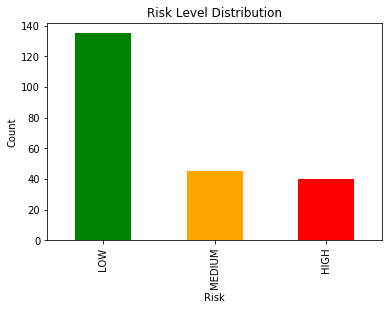

In [8]:
import matplotlib.pyplot as plt

df['risk'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title("Risk Level Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

In [9]:
df.groupby('hour').size()

hour
13    128
14     92
dtype: int64

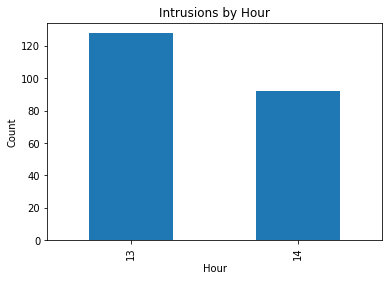

In [10]:
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Intrusions by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

In [11]:
df['duration'].describe()

count    220.000000
mean       1.328545
std        3.707662
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       21.280000
Name: duration, dtype: float64

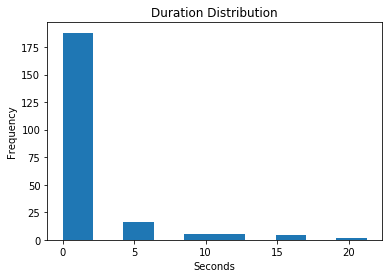

In [12]:
df['duration'].plot(kind='hist', bins=10)
plt.title("Duration Distribution")
plt.xlabel("Seconds")
plt.show()

In [13]:
df.groupby('risk')['duration'].mean()

risk
HIGH      5.39225
LOW       0.00000
MEDIUM    1.70200
Name: duration, dtype: float64

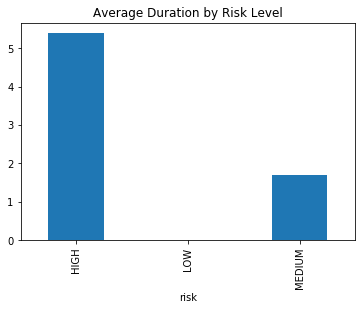

In [14]:
df.groupby('risk')['duration'].mean().plot(kind='bar')
plt.title("Average Duration by Risk Level")
plt.show()

In [15]:
df.groupby(['hour','risk']).size().unstack().fillna(0)

risk,HIGH,LOW,MEDIUM
hour,,,
13,28,71,29
14,12,64,16


In [16]:
high_risk = df[df['risk'] == 'HIGH']
high_risk.groupby('hour').size()

hour
13    28
14    12
dtype: int64

In [17]:
df.groupby('risk')['duration'].mean()

risk
HIGH      5.39225
LOW       0.00000
MEDIUM    1.70200
Name: duration, dtype: float64

In [18]:
df['risk'].value_counts(normalize=True) * 100

LOW       61.363636
MEDIUM    20.454545
HIGH      18.181818
Name: risk, dtype: float64

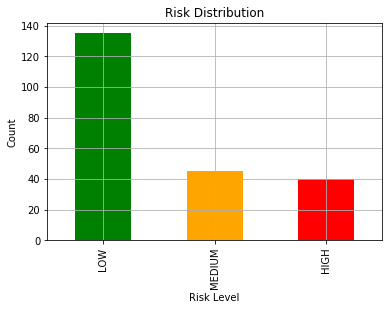

In [19]:
import matplotlib.pyplot as plt

df['risk'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title("Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.grid()
plt.show()